In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
upi_df = pd.read_csv("/Users/chahatjain/Downloads/upi_transactions_2024.csv")


In [6]:
upi_df.head(5)

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


In [7]:
upi_df.describe()

,amount (INR),fraud_flag,hour_of_day,is_weekend
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,1311.756036,0.001920,14.681032,0.285348
std,1848.059224,0.043776,5.188304,0.451581
min,10.000000,0.000000,0.000000,0.000000
25%,288.000000,0.000000,11.000000,0.000000
50%,629.000000,0.000000,15.000000,0.000000
75%,1596.000000,0.000000,19.000000,1.000000
max,42099.000000,1.000000,23.000000,1.000000


In [8]:
upi_df.shape

(250000, 17)

In [9]:
upi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   transaction id      250000 non-null  object
 1   timestamp           250000 non-null  object
 2   transaction type    250000 non-null  object
 3   merchant_category   250000 non-null  object
 4   amount (INR)        250000 non-null  int64 
 5   transaction_status  250000 non-null  object
 6   sender_age_group    250000 non-null  object
 7   receiver_age_group  250000 non-null  object
 8   sender_state        250000 non-null  object
 9   sender_bank         250000 non-null  object
 10  receiver_bank       250000 non-null  object
 11  device_type         250000 non-null  object
 12  network_type        250000 non-null  object
 13  fraud_flag          250000 non-null  int64 
 14  hour_of_day         250000 non-null  int64 
 15  day_of_week         250000 non-null  object
 16  is

In [10]:
upi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   transaction id      250000 non-null  object
 1   timestamp           250000 non-null  object
 2   transaction type    250000 non-null  object
 3   merchant_category   250000 non-null  object
 4   amount (INR)        250000 non-null  int64 
 5   transaction_status  250000 non-null  object
 6   sender_age_group    250000 non-null  object
 7   receiver_age_group  250000 non-null  object
 8   sender_state        250000 non-null  object
 9   sender_bank         250000 non-null  object
 10  receiver_bank       250000 non-null  object
 11  device_type         250000 non-null  object
 12  network_type        250000 non-null  object
 13  fraud_flag          250000 non-null  int64 
 14  hour_of_day         250000 non-null  int64 
 15  day_of_week         250000 non-null  object
 16  is

In [11]:
upi_df['timestamp'] = upi_df['timestamp'].astype(str)

In [12]:
upi_df['timestamp'].dtype

dtype('O')

In [13]:
upi_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   transaction id      250000 non-null  object
 1   timestamp           250000 non-null  object
 2   transaction type    250000 non-null  object
 3   merchant_category   250000 non-null  object
 4   amount (INR)        250000 non-null  int64 
 5   transaction_status  250000 non-null  object
 6   sender_age_group    250000 non-null  object
 7   receiver_age_group  250000 non-null  object
 8   sender_state        250000 non-null  object
 9   sender_bank         250000 non-null  object
 10  receiver_bank       250000 non-null  object
 11  device_type         250000 non-null  object
 12  network_type        250000 non-null  object
 13  fraud_flag          250000 non-null  int64 
 14  hour_of_day         250000 non-null  int64 
 15  day_of_week         250000 non-null  object
 16  is

In [14]:
upi_df['date_column'] = upi_df['timestamp'].str.extract(r'(\d{4}[\d\-]+[\d\-]+)')

In [15]:
upi_df.tail()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend,date_column
249995,TXN0000249996,2024-11-08 22:41:43,Recharge,Food,373,SUCCESS,36-45,26-35,Telangana,ICICI,HDFC,iOS,5G,0,22,Friday,0,2024-11-08
249996,TXN0000249997,2024-12-15 02:58:03,P2P,Utilities,2025,SUCCESS,36-45,26-35,Rajasthan,HDFC,Yes Bank,Android,5G,0,2,Sunday,1,2024-12-15
249997,TXN0000249998,2024-11-27 16:33:25,P2P,Food,468,SUCCESS,26-35,18-25,West Bengal,ICICI,ICICI,Android,4G,0,16,Wednesday,0,2024-11-27
249998,TXN0000249999,2024-01-05 13:31:30,Recharge,Healthcare,284,SUCCESS,18-25,36-45,Andhra Pradesh,Axis,ICICI,iOS,4G,0,13,Friday,0,2024-01-05
249999,TXN0000250000,2024-01-17 15:23:07,P2P,Entertainment,531,SUCCESS,18-25,26-35,Telangana,Axis,Yes Bank,Android,4G,0,15,Wednesday,0,2024-01-17


In [16]:
upi_df['time_column'] = upi_df['timestamp'].str.extract(r'(\d{2}:\d{2}:\d{2})')

In [17]:
upi_df.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend,date_column,time_column
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0,2024-10-08,15:17:28
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0,2024-04-11,06:56:00
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0,2024-04-02,13:27:18
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1,2024-01-07,10:09:17
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0,2024-01-23,19:04:23


In [18]:
upi_df.isna()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend,date_column,time_column
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
249996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
249997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
249998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [19]:
upi_df['date_column'].isna().sum()

np.int64(0)

In [20]:
upi_df.isna().sum()

transaction id        0
timestamp             0
transaction type      0
merchant_category     0
amount (INR)          0
transaction_status    0
sender_age_group      0
receiver_age_group    0
sender_state          0
sender_bank           0
receiver_bank         0
device_type           0
network_type          0
fraud_flag            0
hour_of_day           0
day_of_week           0
is_weekend            0
date_column           0
time_column           0
dtype: int64

In [21]:
upi_df.columns

Index(['transaction id', 'timestamp', 'transaction type', 'merchant_category',
       'amount (INR)', 'transaction_status', 'sender_age_group',
       'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank',
       'device_type', 'network_type', 'fraud_flag', 'hour_of_day',
       'day_of_week', 'is_weekend', 'date_column', 'time_column'],
      dtype='object')

In [22]:
upi_df.rename(columns={'transaction id':'transaction_id'})

,transaction_id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend,date_column,time_column
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0,2024-10-08,15:17:28
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0,2024-04-11,06:56:00
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0,2024-04-02,13:27:18
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1,2024-01-07,10:09:17
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0,2024-01-23,19:04:23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,TXN0000249996,2024-11-08 22:41:43,Recharge,Food,373,SUCCESS,36-45,26-35,Telangana,ICICI,HDFC,iOS,5G,0,22,Friday,0,2024-11-08,22:41:43
249996,TXN0000249997,2024-12-15 02:58:03,P2P,Utilities,2025,SUCCESS,36-45,26-35,Rajasthan,HDFC,Yes Bank,Android,5G,0,2,Sunday,1,2024-12-15,02:58:03
249997,TXN0000249998,2024-11-27 16:33:25,P2P,Food,468,SUCCESS,26-35,18-25,West Bengal,ICICI,ICICI,Android,4G,0,16,Wednesday,0,2024-11-27,16:33:25
249998,TXN0000249999,2024-01-05 13:31:30,Recharge,Healthcare,284,SUCCESS,18-25,36-45,Andhra Pradesh,Axis,ICICI,iOS,4G,0,13,Friday,0,2024-01-05,13:31:30


In [23]:
upi_df.duplicated().sum()

np.int64(0)

In [24]:
upi_df.head(20)

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend,date_column,time_column
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0,2024-10-08,15:17:28
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0,2024-04-11,06:56:00
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0,2024-04-02,13:27:18
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1,2024-01-07,10:09:17
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0,2024-01-23,19:04:23
5,TXN0000000006,2024-10-07 22:32:07,P2P,Food,91,SUCCESS,36-45,18-25,Karnataka,IndusInd,Yes Bank,Android,3G,0,22,Monday,0,2024-10-07,22:32:07
6,TXN0000000007,2024-02-08 10:25:57,P2P,Other,314,SUCCESS,36-45,18-25,Telangana,HDFC,IndusInd,Android,4G,0,10,Thursday,0,2024-02-08,10:25:57
7,TXN0000000008,2024-10-27 18:47:02,P2P,Utilities,264,SUCCESS,46-55,36-45,Maharashtra,Yes Bank,SBI,Android,5G,0,18,Sunday,1,2024-10-27,18:47:02
8,TXN0000000009,2024-11-21 09:39:16,P2P,Other,887,SUCCESS,46-55,36-45,Maharashtra,Kotak,HDFC,Android,4G,0,9,Thursday,0,2024-11-21,09:39:16
9,TXN0000000010,2024-11-11 15:58:56,P2M,Grocery,3260,SUCCESS,46-55,18-25,Delhi,SBI,HDFC,Android,4G,0,15,Monday,0,2024-11-11,15:58:56


In [25]:
upi_df.loc[upi_df['fraud_flag'] == 1]

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend,date_column,time_column
740,TXN0000000741,2024-10-30 17:37:20,Recharge,Healthcare,361,SUCCESS,18-25,18-25,Karnataka,SBI,ICICI,Android,5G,1,17,Wednesday,0,2024-10-30,17:37:20
1228,TXN0000001229,2024-06-22 00:21:52,P2P,Fuel,479,SUCCESS,26-35,36-45,Karnataka,SBI,HDFC,iOS,4G,1,0,Saturday,1,2024-06-22,00:21:52
2777,TXN0000002778,2024-06-12 19:46:25,P2P,Food,162,SUCCESS,18-25,36-45,Gujarat,PNB,ICICI,iOS,4G,1,19,Wednesday,0,2024-06-12,19:46:25
3761,TXN0000003762,2024-01-30 19:57:42,P2M,Transport,754,SUCCESS,26-35,36-45,Karnataka,ICICI,SBI,Android,5G,1,19,Tuesday,0,2024-01-30,19:57:42
3962,TXN0000003963,2024-11-28 21:36:02,P2P,Healthcare,402,SUCCESS,26-35,36-45,Maharashtra,Yes Bank,Kotak,Web,4G,1,21,Thursday,0,2024-11-28,21:36:02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
247717,TXN0000247718,2024-09-29 07:32:05,P2M,Grocery,356,SUCCESS,26-35,26-35,Rajasthan,SBI,IndusInd,Android,WiFi,1,7,Sunday,1,2024-09-29,07:32:05
247880,TXN0000247881,2024-01-18 17:32:56,P2P,Other,450,SUCCESS,26-35,36-45,Maharashtra,Axis,Kotak,Android,4G,1,17,Thursday,0,2024-01-18,17:32:56
248661,TXN0000248662,2024-11-21 19:26:08,P2M,Food,152,SUCCESS,18-25,46-55,Karnataka,Kotak,HDFC,Android,4G,1,19,Thursday,0,2024-11-21,19:26:08
248716,TXN0000248717,2024-12-19 19:45:07,P2P,Fuel,457,SUCCESS,18-25,26-35,Gujarat,Axis,HDFC,Android,4G,1,19,Thursday,0,2024-12-19,19:45:07


In [32]:
upi_df.loc[(upi_df['amount (INR)'] == 0) | (upi_df['amount (INR)'] < 0)]

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend,date_column,time_column


In [34]:
upi_df['amount (INR)'].describe()

count    250000.000000
mean       1311.756036
std        1848.059224
min          10.000000
25%         288.000000
50%         629.000000
75%        1596.000000
max       42099.000000
Name: amount (INR), dtype: float64

<Axes: xlabel='amount (INR)', ylabel='Count'>

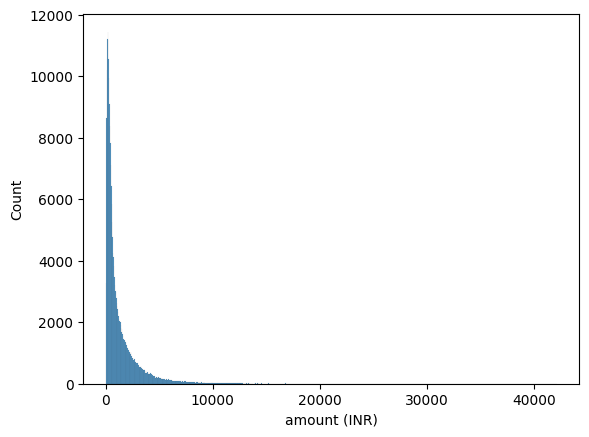

In [37]:
sns.histplot(upi_df['amount (INR)'])

In [39]:
upi_df.loc[upi_df['fraud_flag'] == 1].count()

transaction id        480
timestamp             480
transaction type      480
merchant_category     480
amount (INR)          480
transaction_status    480
sender_age_group      480
receiver_age_group    480
sender_state          480
sender_bank           480
receiver_bank         480
device_type           480
network_type          480
fraud_flag            480
hour_of_day           480
day_of_week           480
is_weekend            480
date_column           480
time_column           480
dtype: int64

In [42]:
(upi_df.loc[upi_df['fraud_flag'] == 1].count()/upi_df['fraud_flag'].count())*100

transaction id        0.192
timestamp             0.192
transaction type      0.192
merchant_category     0.192
amount (INR)          0.192
transaction_status    0.192
sender_age_group      0.192
receiver_age_group    0.192
sender_state          0.192
sender_bank           0.192
receiver_bank         0.192
device_type           0.192
network_type          0.192
fraud_flag            0.192
hour_of_day           0.192
day_of_week           0.192
is_weekend            0.192
date_column           0.192
time_column           0.192
dtype: float64

In [52]:
upi_df.loc[upi_df['fraud_flag'] == 1].groupby(['transaction type']).count()

,transaction id,timestamp,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend,date_column,time_column
transaction type,,,,,,,,,,,,,,,,,,
Bill Payment,77,77,77,77,77,77,77,77,77,77,77,77,77,77,77,77,77,77
P2M,167,167,167,167,167,167,167,167,167,167,167,167,167,167,167,167,167,167
P2P,206,206,206,206,206,206,206,206,206,206,206,206,206,206,206,206,206,206
Recharge,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30,30


<Axes: xlabel='merchant_category', ylabel='count'>

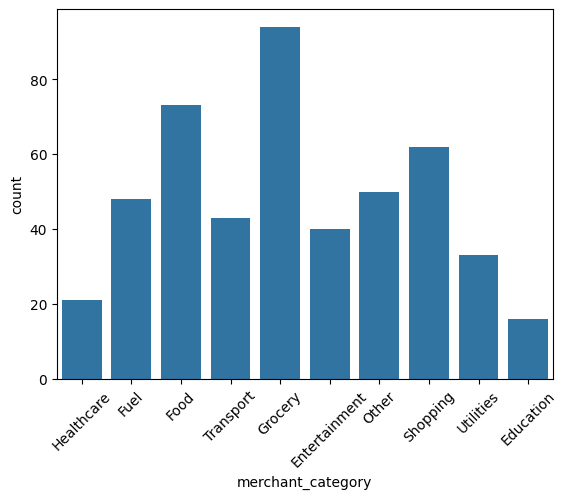

In [69]:
fraud_rows = upi_df.loc[upi_df['fraud_flag']==1]
plt.xticks(rotation = 45)
sns.countplot(x='merchant_category',data = fraud_rows)

<Axes: xlabel='transaction type', ylabel='count'>

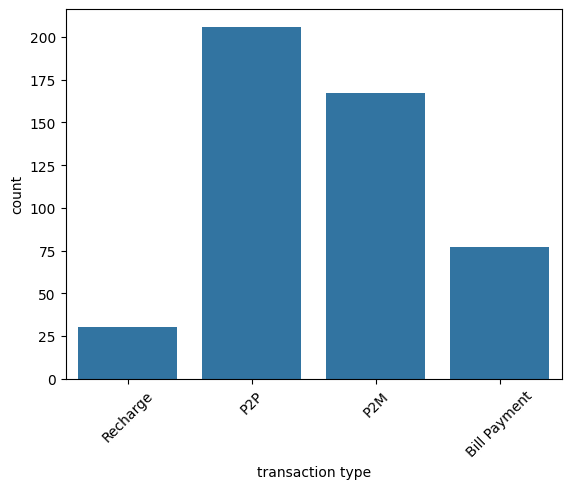

In [70]:
fraud_rows = upi_df.loc[upi_df['fraud_flag']==1]
plt.xticks(rotation = 45)
sns.countplot(x='transaction type',data = fraud_rows)

<Axes: xlabel='device_type', ylabel='count'>

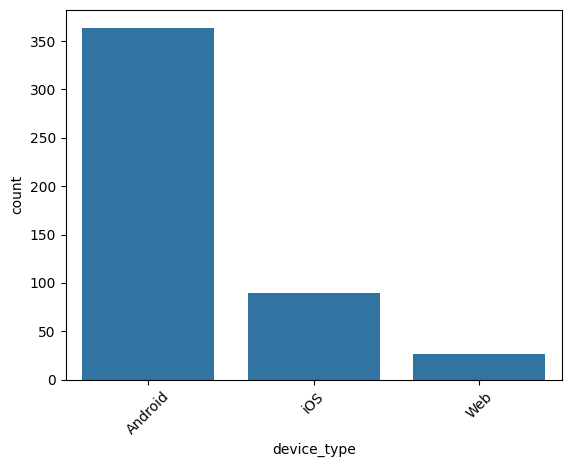

In [71]:
fraud_rows = upi_df.loc[upi_df['fraud_flag']==1]
plt.xticks(rotation = 45)
sns.countplot(x='device_type',data = fraud_rows)

<Axes: xlabel='network_type', ylabel='count'>

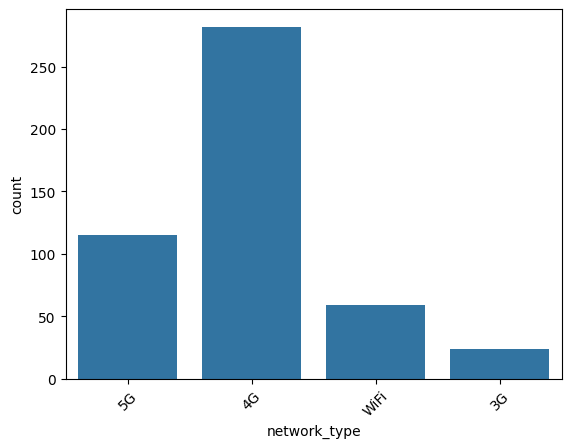

In [72]:
fraud_rows = upi_df.loc[upi_df['fraud_flag']==1]
plt.xticks(rotation = 45)
sns.countplot(x='network_type',data = fraud_rows)

<Axes: xlabel='hour_of_day', ylabel='count'>

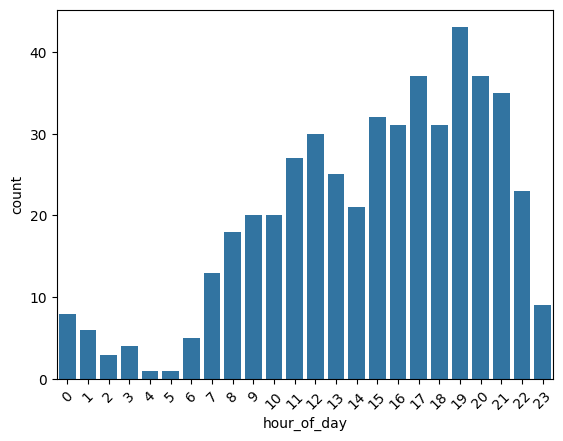

In [73]:
fraud_rows = upi_df.loc[upi_df['fraud_flag']==1]
plt.xticks(rotation = 45)
sns.countplot(x='hour_of_day',data = fraud_rows)

<Axes: xlabel='sender_bank', ylabel='count'>

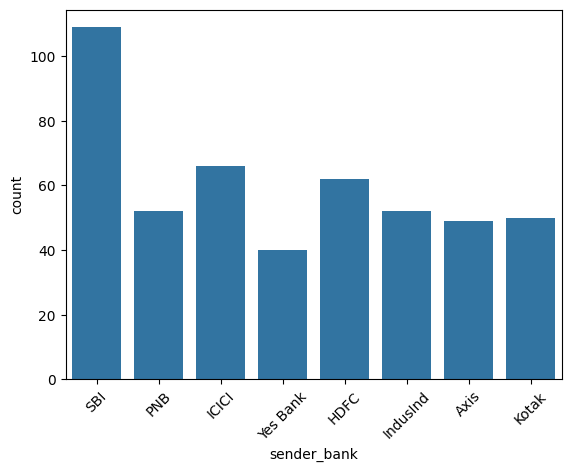

In [76]:
fraud_rows = upi_df.loc[upi_df['fraud_flag']==1]
plt.xticks(rotation = 45)
sns.countplot(x='sender_bank',data = fraud_rows)

<Axes: xlabel='fraud_flag', ylabel='amount (INR)'>

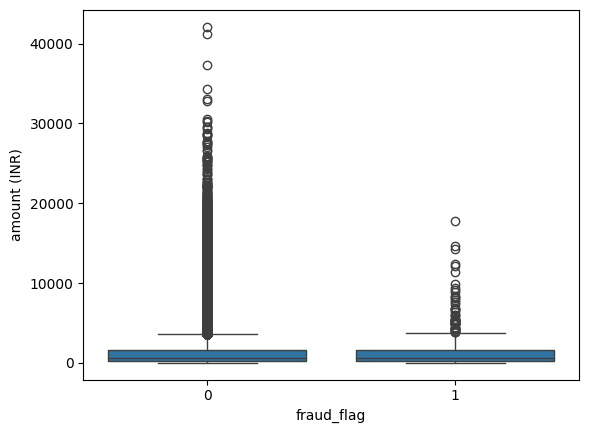

In [87]:

sns.boxplot(x='fraud_flag',y='amount (INR)',data = upi_df)

<Axes: >

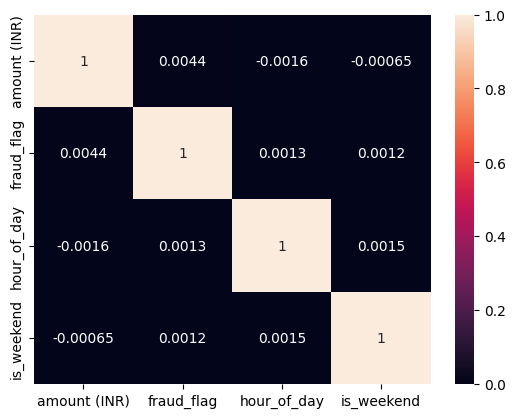

In [91]:
numeric_df = upi_df[['amount (INR)','fraud_flag','hour_of_day','is_weekend']]
upi_mx = numeric_df.corr()
sns.heatmap(upi_mx,annot = True)

In [ ]:
## key insights
Fraud rate ≈ 0.19%
• P2P transactions had highest fraud
• Grocery merchants most fraud-prone
• Android devices showed highest fraud
• 4G networks had most fraud cases
• Fraud peaks around 7 PM
• Fraud transactions tend to be smaller amounts
• SBI appears most in fraudulent sender transactions